### K-Means Clustering
Only use K-Means Clustering when the data is linearly separable

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv("/Users/rachanapandey/Desktop/study_materials/Data Science/Dataset/iris raw.csv")
dataset.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


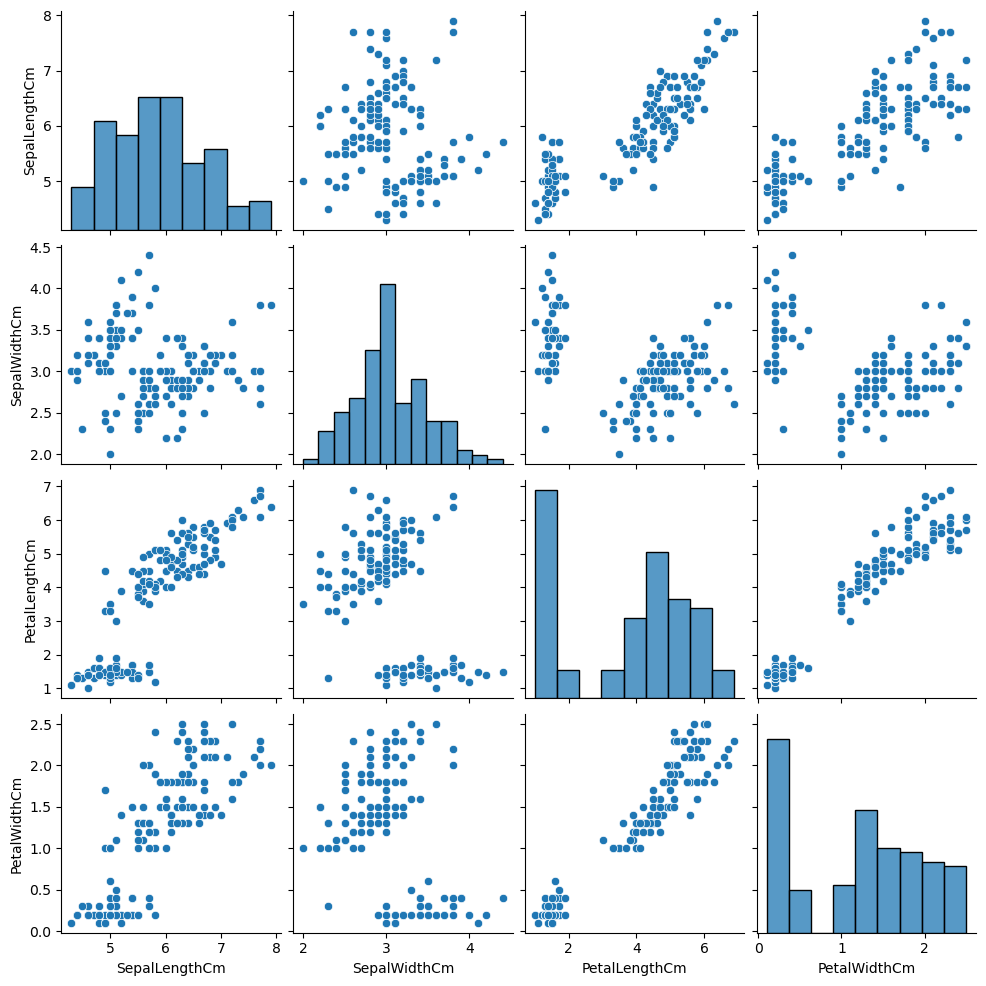

In [3]:
sns.pairplot(data=dataset)
plt.show()

In [4]:
# we need to find the number of k
from sklearn.cluster import KMeans

In [5]:
wcss = []
# using loop to get the best cluster
for i in range(2,21):
    km = KMeans(n_clusters=i, init='k-means++')
    km.fit(dataset)
    wcss.append(km.inertia_) # gives wcss value and we can use that to see the elbow graph


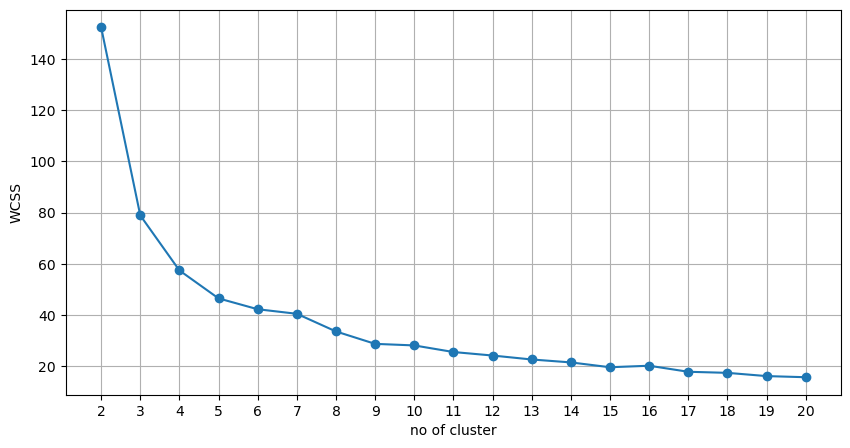

In [6]:
plt.figure(figsize=(10,5))
plt.plot([i for i in range(2,21)], wcss, marker = 'o')
plt.xlabel("no of cluster")
plt.xticks([i for i in range(2,21)]) # to get each number from the loop as x-axis
plt.ylabel("WCSS")
plt.grid(axis='both')
plt.show()
# we can see our elbow point is 3

In [7]:
kmn = KMeans(n_clusters=3)
kmn.fit_predict(dataset) # prediction for what cluster they belong to.

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

In [14]:
kmn.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 1, 1, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2,
       2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1], dtype=int32)

In [8]:
# storing it in a column called predict in the dataset
dataset['predict'] = kmn.fit_predict(dataset)

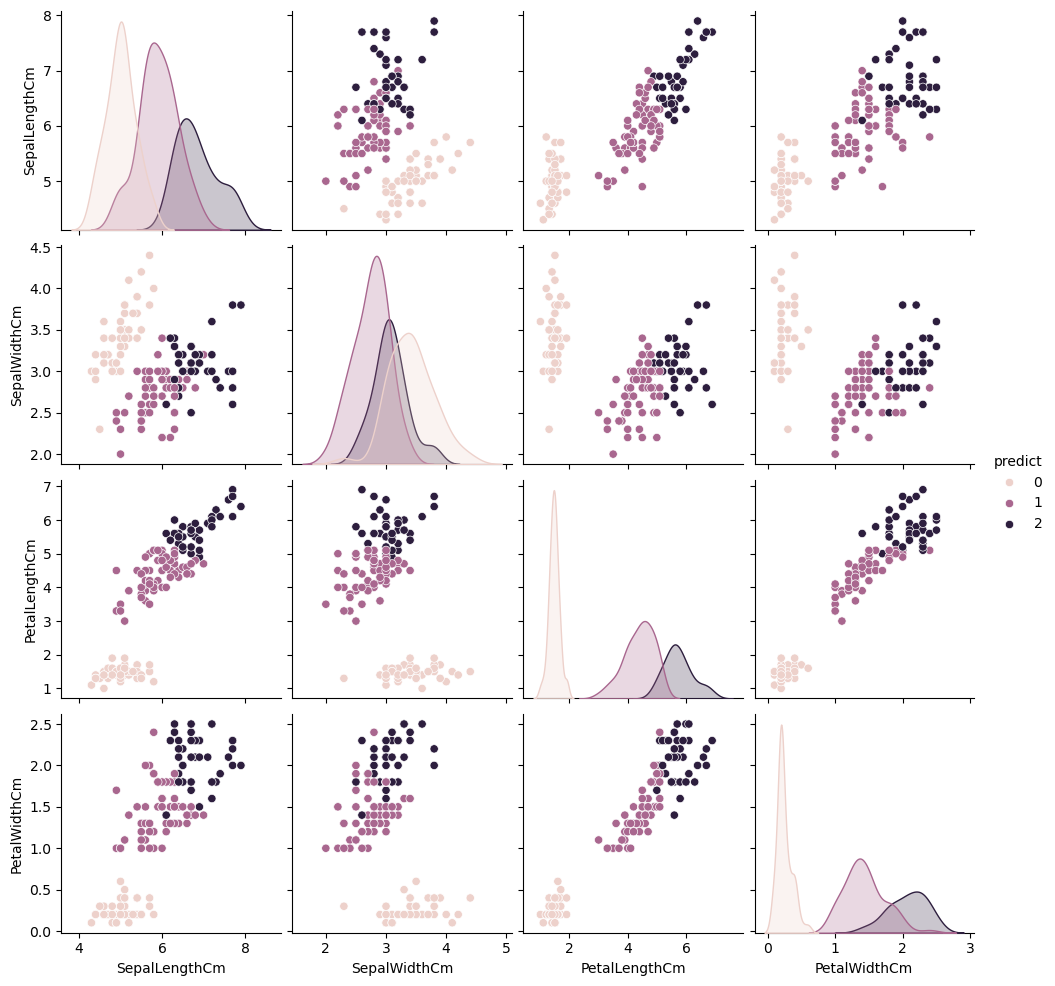

In [9]:
sns.pairplot(data=dataset, hue = "predict")
plt.savefig("KMeans_Predict.jpg")
plt.show()

In [10]:
#let's comapre with the original data we have
org_dataset = pd.read_csv("/Users/rachanapandey/Desktop/study_materials/Data Science/Dataset/iris.csv")


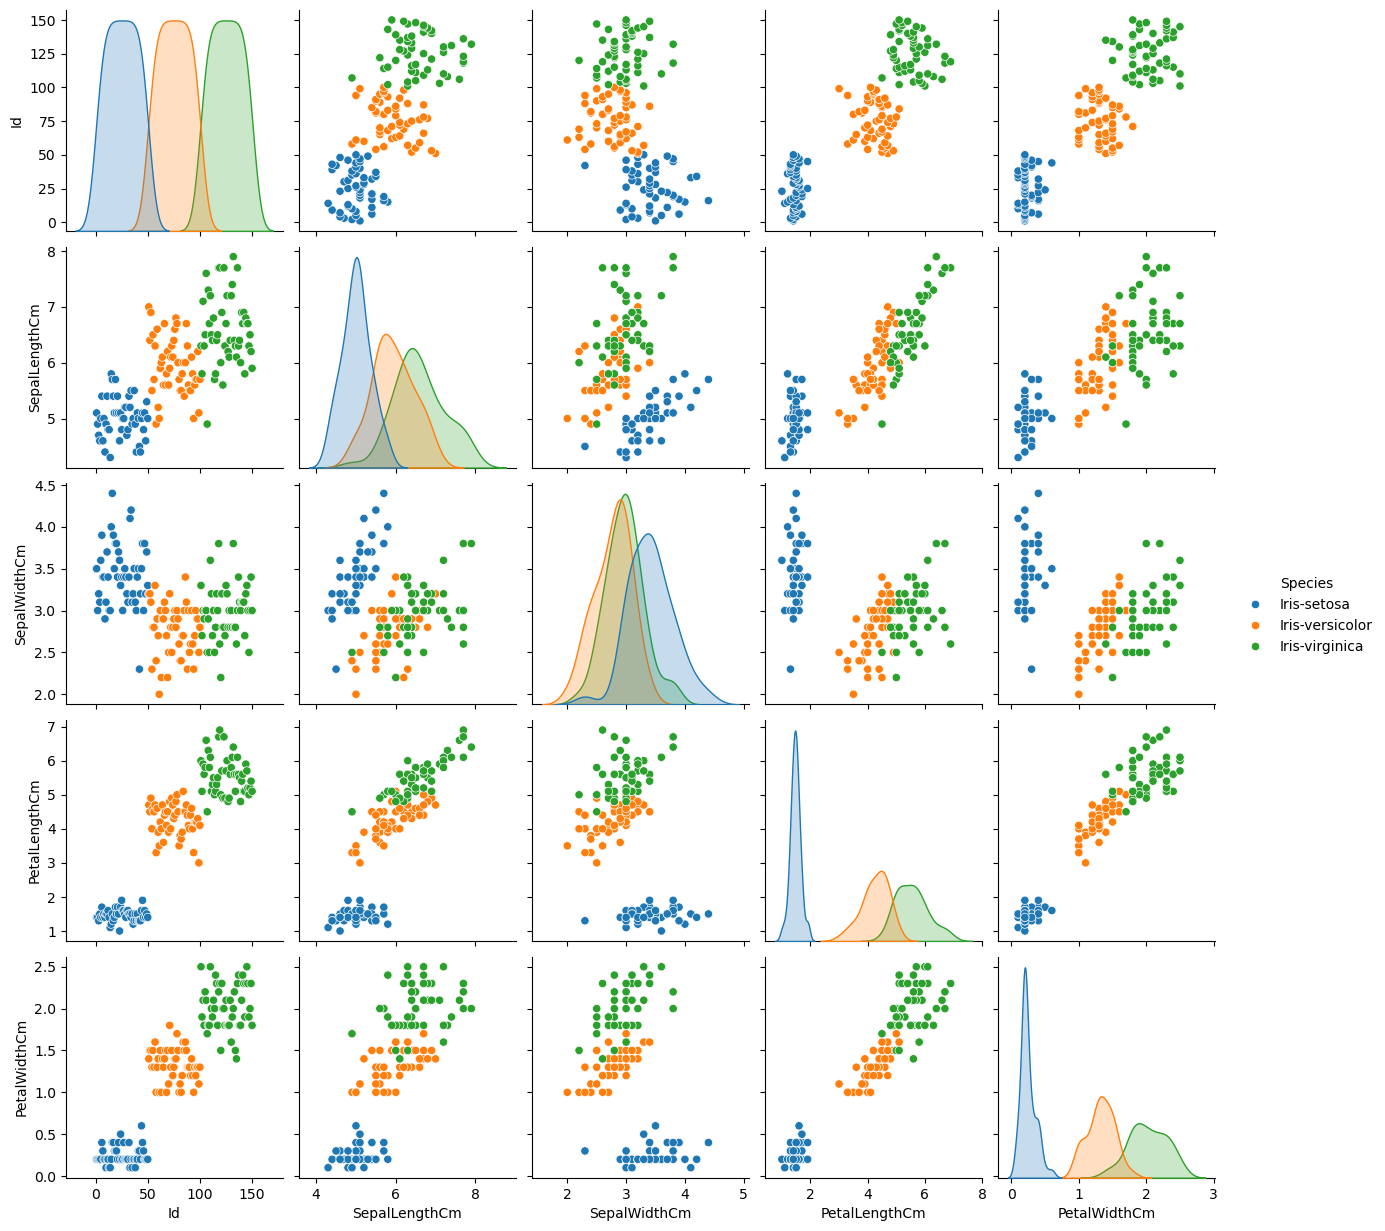

In [11]:
sns.pairplot(data=org_dataset, hue="Species")
# plt.savefig("KMeans_Orginal.jpg")
plt.show()

In [13]:
from sklearn.metrics import silhouette_score

In [19]:
ss=[]
no_c = [j for j in range(2,21)]
for i in range (2,21):
    km1 = KMeans(n_clusters=i)
    km1.fit(dataset)
    ss.append(silhouette_score(dataset, km1.labels_))

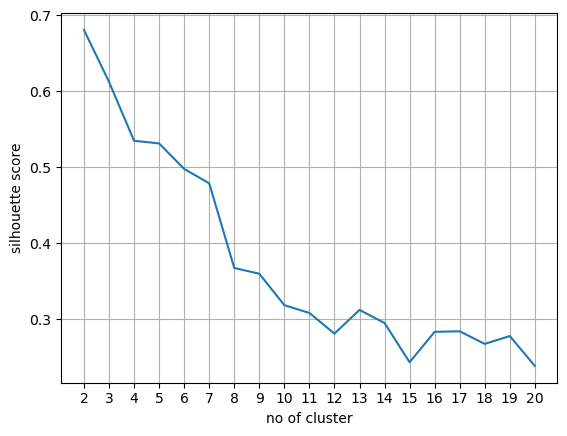

In [22]:
plt.plot(no_c, ss)
plt.xlabel("no of cluster")
plt.ylabel("silhouette score")
plt.xticks(no_c)
plt.grid(axis="both")
plt.show()